
| Column Name            | Meaning                                                                 |
|------------------------|-------------------------------------------------------------------------|
| **Brand**              | The manufacturer of the car (e.g., Tesla, BMW, Honda).                 |
| **Model**              | The specific car model name.                                            |
| **AccelSec**           | Time (in seconds) the car takes to accelerate from 0 to 100 km/h.      |
| **TopSpeed_KmH**       | The top speed the car can reach (in kilometers per hour).              |
| **Range_Km**           | Maximum distance the car can travel on a full charge (in km).          |
| **Battery_Pack Kwh**   | Battery capacity in kilowatt-hours (kWh). Larger battery = more energy.|
| **Efficiency_WhKm**    | How much energy the car uses per kilometer (watt-hours per km). Lower is better. |
| **FastCharge_KmH**     | How many kilometers the car can gain per hour of **fast charging**.    |
| **RapidCharge**        | Indicates if the car supports rapid charging (`Yes` or `No`).          |
| **PowerTrain**         | Type of drivetrain: AWD (All-Wheel Drive), RWD (Rear), or FWD (Front). |
| **PlugType**           | Type of charging plug the car supports (e.g., Type 2 CCS).             |
| **BodyStyle**          | The physical structure of the car (e.g., Sedan, SUV, Hatchback).       |
| **Segment**            | Market segment (e.g., B, C, D) — refers to car size/class.             |
| **Seats**              | Number of passenger seats in the car.                                  |
| **PriceEuro**          | Price of the car in Euros.                                              |

In [1]:
# importing lib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.simplefilter("ignore", UserWarning)

In [4]:
# loading data set
file_path = r"C:\Users\Aayush\Desktop\Codes\sem-6 codes\1 Capstone\car1.csv"
Raw_data = pd.read_csv(file_path)

In [5]:
# hear we have different types of  var
import pandas as pd

def preprocessin_the_data(df):
    global main_data
    try :
        df_info= df.info()
        print("-"*20)
        df_head = df.head()
        print("-"*20)
        staatistic_df = df.describe()
        print("-"*20)
        df_is_null = df.isnull().sum()
        print("-"*20)
        Labled_maodel  = LabelEncoder()
        cat_data = [x for x in df.columns if df[x].unique().dtype == "object"]  
        num_data = [x for x in df.columns if df[x].unique().dtype != "object"]  
        encoded_data = pd.DataFrame()
        for col in cat_data:
            encoded_data[col] = Labled_maodel.fit_transform(df[col].values)
        main_data = pd.concat([encoded_data,df[num_data]],axis=1)  
        return df_head,df_info,staatistic_df,df_is_null,main_data
    except Exception as e:
        print("The error is :",e)

preprocessin_the_data(Raw_data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             102 non-null    object 
 1   Model             102 non-null    object 
 2   AccelSec          102 non-null    float64
 3   TopSpeed_KmH      102 non-null    int64  
 4   Range_Km          102 non-null    int64  
 5   Battery_Pack Kwh  102 non-null    float64
 6   Efficiency_WhKm   102 non-null    int64  
 7   FastCharge_KmH    102 non-null    int64  
 8   RapidCharge       102 non-null    object 
 9   PowerTrain        102 non-null    object 
 10  PlugType          102 non-null    object 
 11  BodyStyle         102 non-null    object 
 12  Segment           102 non-null    object 
 13  Seats             102 non-null    int64  
 14  PriceEuro         102 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 12.1+ KB
--------------------
------------

(        Brand                          Model  AccelSec  TopSpeed_KmH  \
 0       Tesla  Model 3 Long Range Dual Motor       4.6           233   
 1  Volkswagen                      ID.3 Pure      10.0           160   
 2    Polestar                              2       4.7           210   
 3         BMW                            iX3       6.8           180   
 4       Honda                              e       9.5           145   
 
    Range_Km  Battery_Pack Kwh  Efficiency_WhKm  FastCharge_KmH RapidCharge  \
 0       460              70.0              161             940         Yes   
 1       270              45.0              167             250         Yes   
 2       400              75.0              181             620         Yes   
 3       360              74.0              206             560         Yes   
 4       170              28.5              168             190         Yes   
 
   PowerTrain    PlugType  BodyStyle Segment  Seats  PriceEuro  
 0        AWD  Type

In [6]:
def load_data(file_path):
    return pd.read_csv(file_path)
load_data(file_path)

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Battery_Pack Kwh,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro
0,Tesla,Model 3 Long Range Dual Motor,4.6,233,460,70.0,161,940,Yes,AWD,Type 2 CCS,Sedan,D,5,55480
1,Volkswagen,ID.3 Pure,10.0,160,270,45.0,167,250,Yes,RWD,Type 2 CCS,Hatchback,C,5,30000
2,Polestar,2,4.7,210,400,75.0,181,620,Yes,AWD,Type 2 CCS,Liftback,D,5,56440
3,BMW,iX3,6.8,180,360,74.0,206,560,Yes,RWD,Type 2 CCS,SUV,D,5,68040
4,Honda,e,9.5,145,170,28.5,168,190,Yes,RWD,Type 2 CCS,Hatchback,B,4,32997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,Nissan,Ariya 63kWh,7.5,160,330,63.0,191,440,Yes,FWD,Type 2 CCS,Hatchback,C,5,45000
98,Audi,e-tron S Sportback 55 quattro,4.5,210,335,86.5,258,540,Yes,AWD,Type 2 CCS,SUV,E,5,96050
99,Nissan,Ariya e-4ORCE 63kWh,5.9,200,325,63.0,194,440,Yes,AWD,Type 2 CCS,Hatchback,C,5,50000
100,Nissan,Ariya e-4ORCE 87kWh Performance,5.1,200,375,87.0,232,450,Yes,AWD,Type 2 CCS,Hatchback,C,5,65000


In [7]:
main_data

,Brand,Model,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,AccelSec,TopSpeed_KmH,Range_Km,Battery_Pack Kwh,Efficiency_WhKm,FastCharge_KmH,Seats,PriceEuro
0,30,47,1,0,2,7,3,4.6,233,460,70.0,161,940,5,55480
1,31,34,1,2,2,1,2,10.0,160,270,45.0,167,250,5,30000
2,23,0,1,0,2,2,3,4.7,210,400,75.0,181,620,5,56440
3,2,101,1,2,2,6,3,6.8,180,360,74.0,206,560,5,68040
4,9,79,1,2,2,1,1,9.5,145,170,28.5,168,190,4,32997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,20,6,1,1,2,1,2,7.5,160,330,63.0,191,440,5,45000
98,1,95,1,0,2,6,4,4.5,210,335,86.5,258,540,5,96050
99,20,8,1,0,2,1,2,5.9,200,325,63.0,194,440,5,50000
100,20,10,1,0,2,1,2,5.1,200,375,87.0,232,450,5,65000


In [8]:
Independent_Target = main_data[['Brand', 'Model', 'AccelSec', 'TopSpeed_KmH',
       'Battery_Pack Kwh', 'Efficiency_WhKm', 'FastCharge_KmH', 'RapidCharge',
       'PowerTrain', 'PlugType', 'BodyStyle', 'Segment', 'Seats', 'PriceEuro']]
Dependent_Target = main_data['Range_Km']

## Performing EDA 

In [9]:
Independent_Target = Raw_data[['Brand', 'Model', 'AccelSec', 'TopSpeed_KmH',
       'Battery_Pack Kwh', 'Efficiency_WhKm', 'FastCharge_KmH', 'RapidCharge',
       'PowerTrain', 'PlugType', 'BodyStyle', 'Segment', 'Seats', 'PriceEuro']]
Dependent_Target = Raw_data['Range_Km']

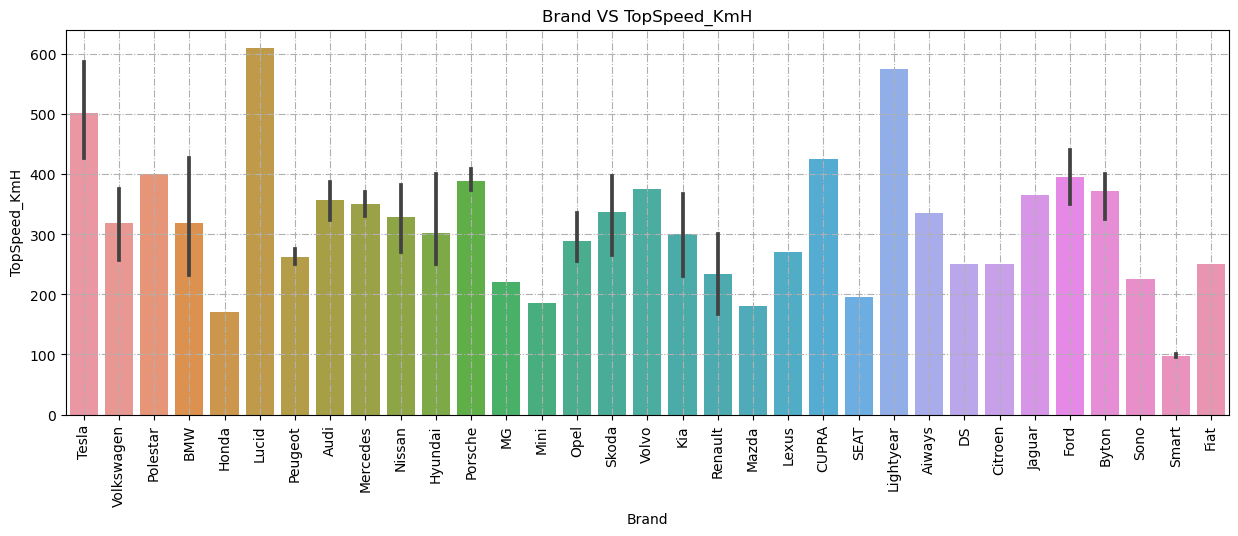

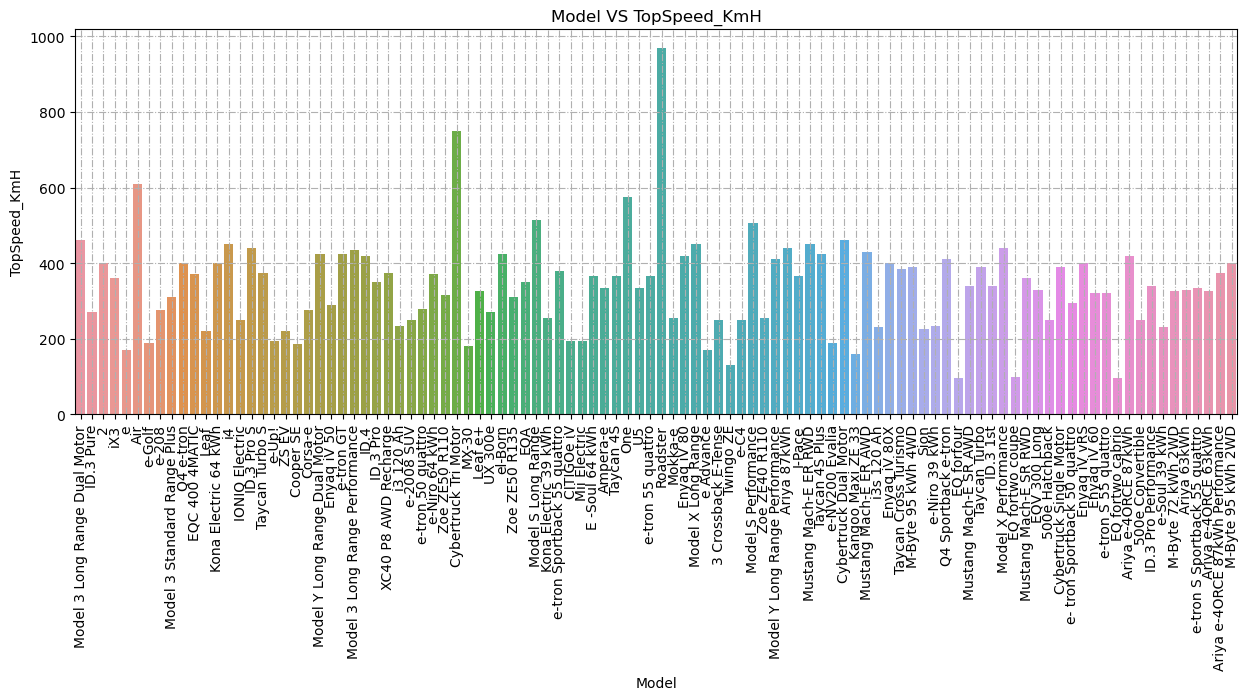

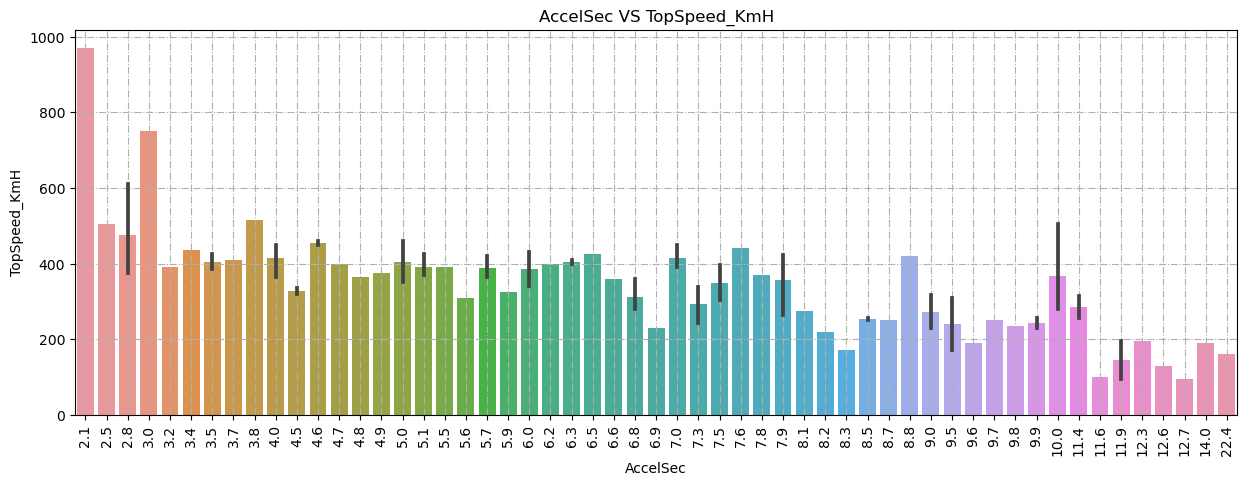

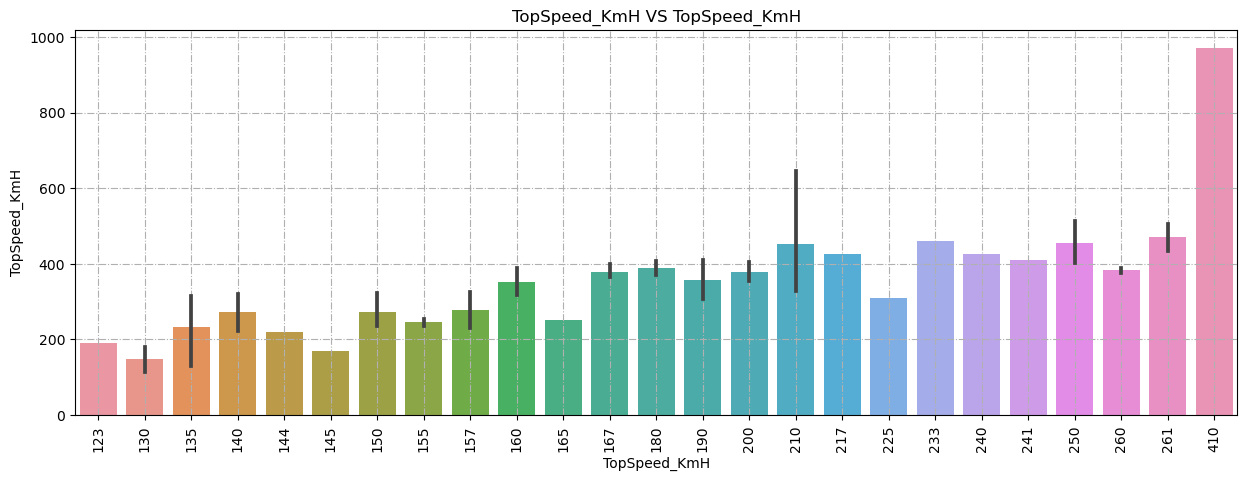

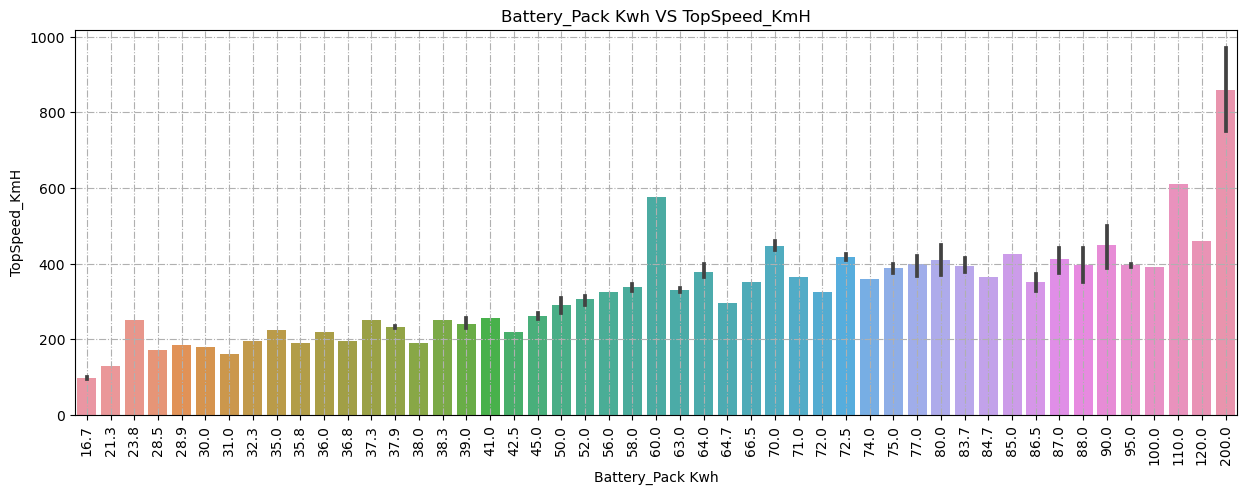

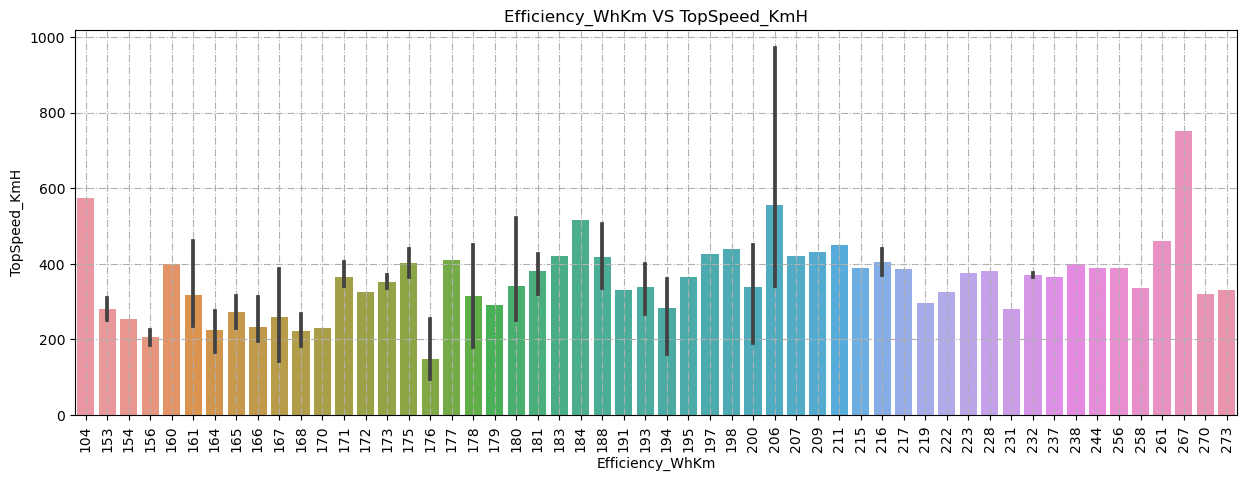

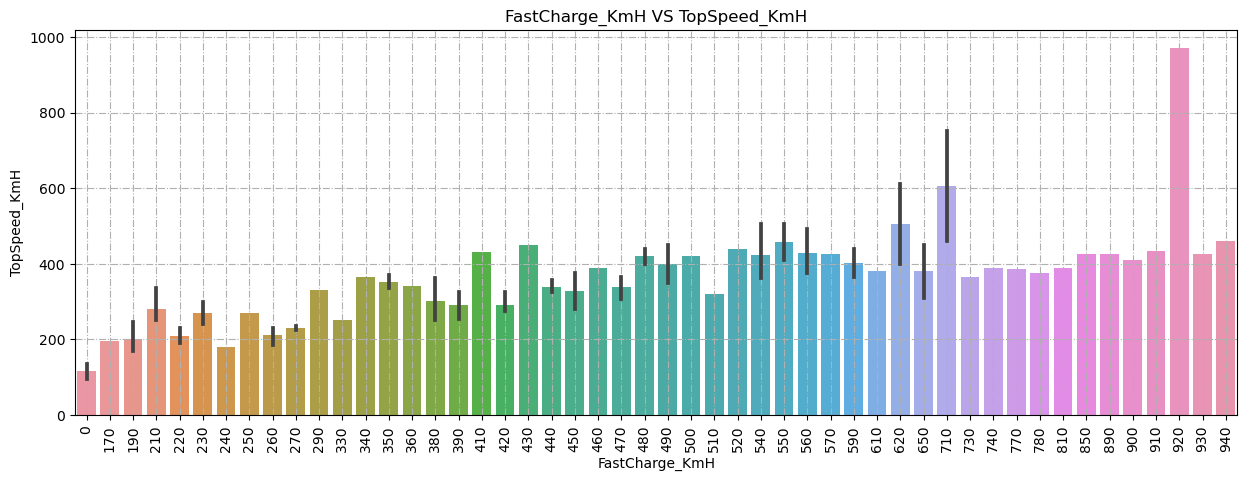

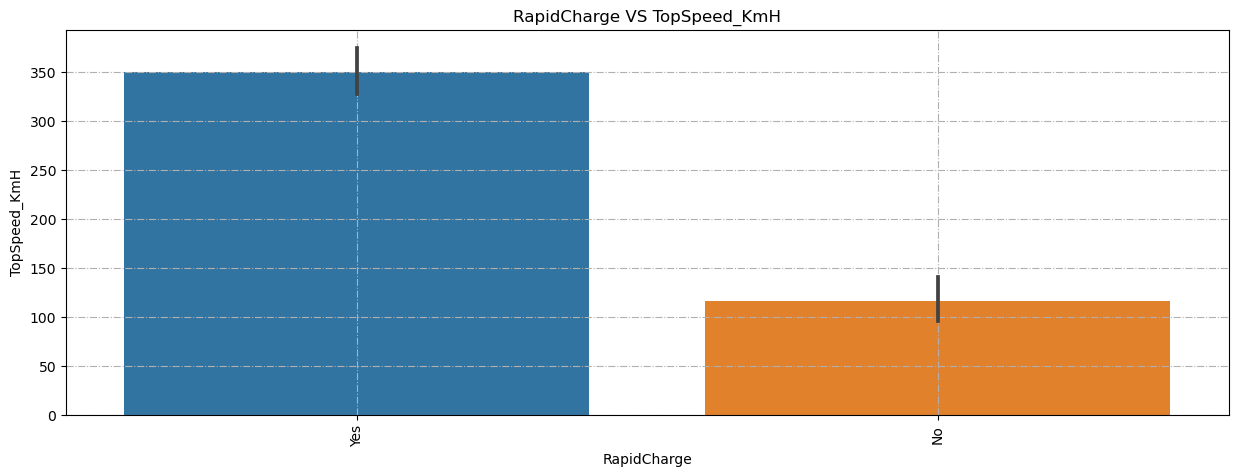

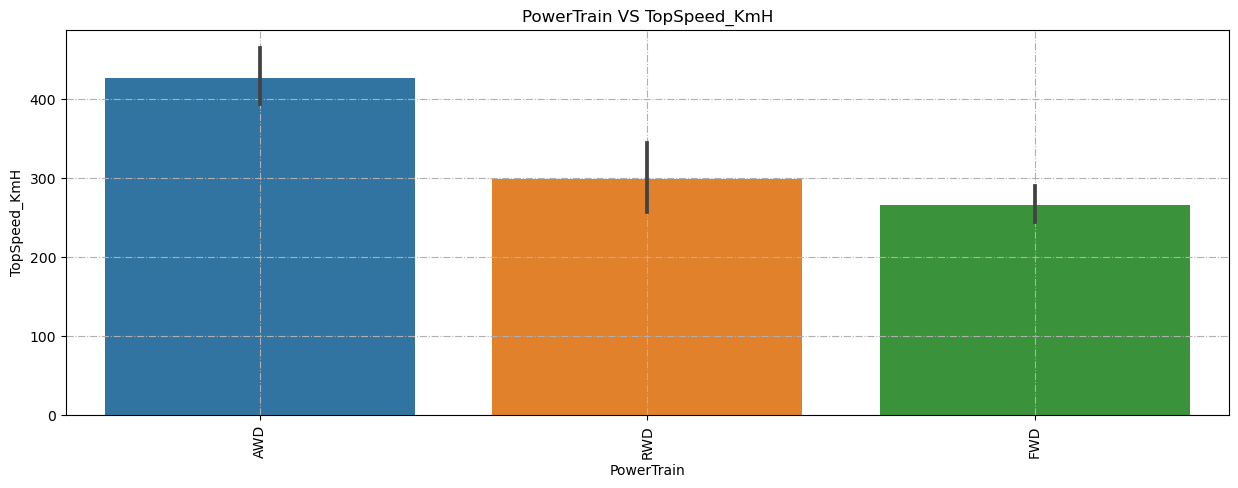

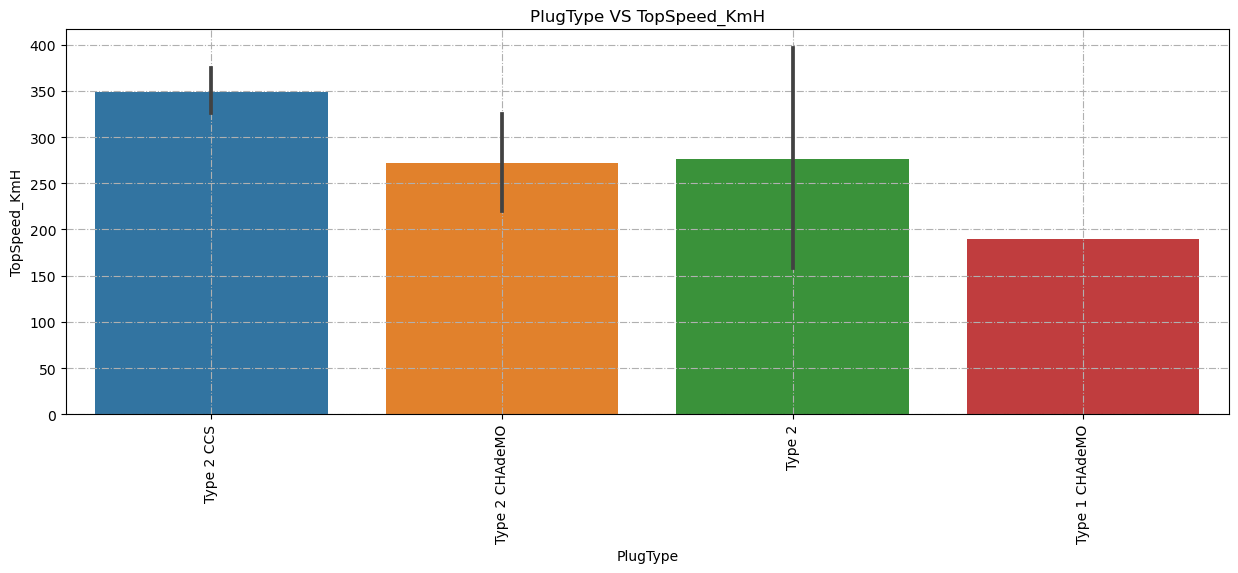

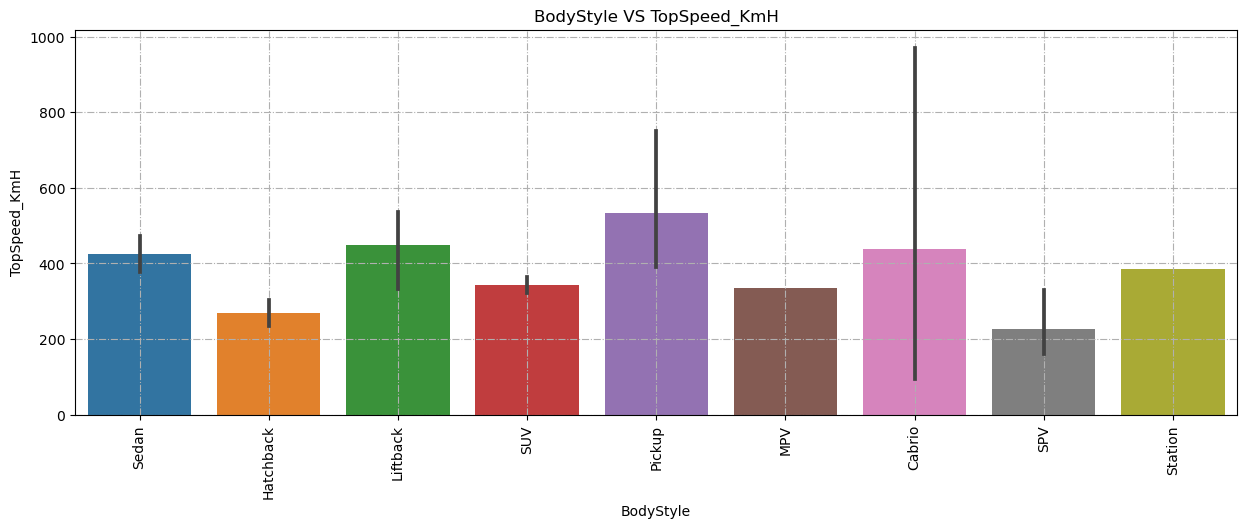

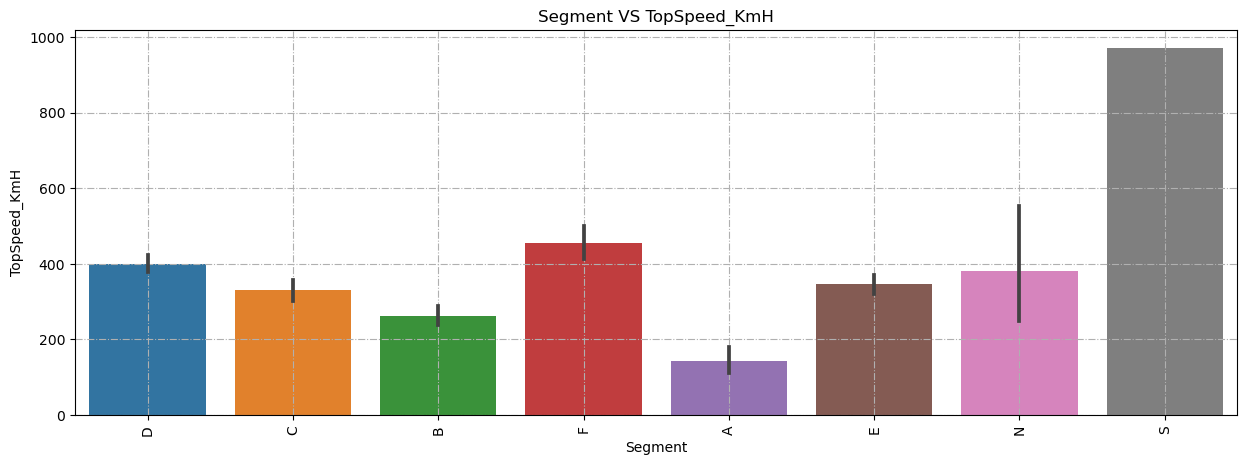

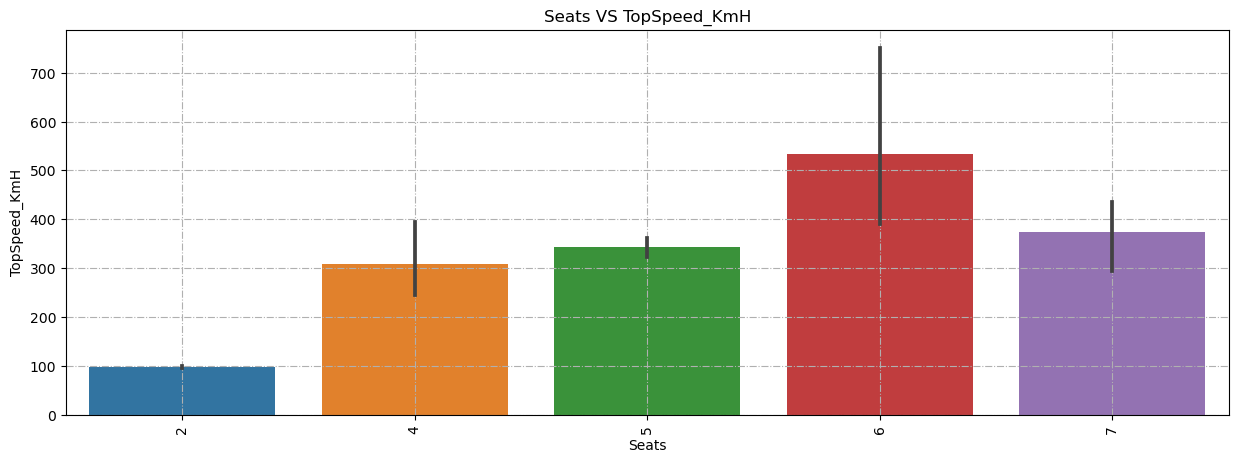

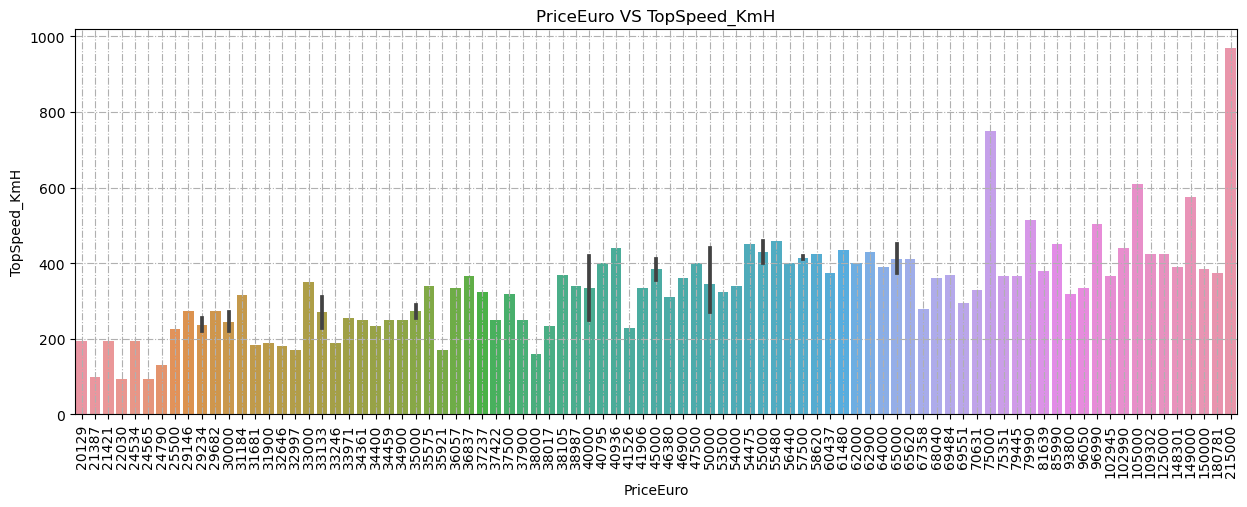

In [10]:
try:
    for kk in Independent_Target:
        plt.figure(figsize=(15,5))
        sns.barplot(x = kk , y = Dependent_Target ,data =Raw_data)
        plt.xlabel(f"{kk}")
        plt.ylabel("TopSpeed_KmH")
        plt.title(f"{kk} VS TopSpeed_KmH")
        plt.xticks(rotation=(90))
        plt.grid(linestyle='-.')
        
        plt.show()
except Exception as e:
    print(e)

,Brand,Model,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,AccelSec,TopSpeed_KmH,Range_Km,Battery_Pack Kwh,Efficiency_WhKm,FastCharge_KmH,Seats,PriceEuro
Brand,1.000000,-0.374293,-0.187211,0.057689,-0.230388,-0.272748,-0.007515,0.063793,0.100370,0.090478,0.016965,-0.199177,0.091987,0.090579,-0.039309
Model,-0.374293,1.000000,0.134942,-0.009707,0.012866,0.236974,0.100538,-0.052319,0.076287,-0.075824,-0.052554,0.021179,0.049924,-0.023433,0.188390
RapidCharge,-0.187211,0.134942,1.000000,-0.275357,0.538957,0.222576,0.192999,-0.515392,0.251837,0.400902,0.342255,0.106887,0.450928,0.422935,0.198799
PowerTrain,0.057689,-0.009707,-0.275357,1.000000,-0.040168,-0.352060,-0.498338,0.520857,-0.560318,-0.452590,-0.486013,-0.394311,-0.481449,-0.279251,-0.561468
PlugType,-0.230388,0.012866,0.538957,-0.040168,1.000000,0.065151,-0.162837,-0.260075,-0.009561,0.131002,0.107531,-0.027849,0.211307,-0.029869,0.000910
BodyStyle,-0.272748,0.236974,0.222576,-0.352060,0.065151,1.000000,0.425803,-0.349487,0.342471,0.227357,0.300373,0.378294,0.420280,0.342409,0.327366
Segment,-0.007515,0.100538,0.192999,-0.498338,-0.162837,0.425803,1.000000,-0.452096,0.671051,0.633275,0.718055,0.622253,0.605605,0.420071,0.736304
AccelSec,0.063793,-0.052319,-0.515392,0.520857,-0.260075,-0.349487,-0.452096,1.000000,-0.786146,-0.677877,-0.678295,-0.382600,-0.782624,-0.175620,-0.627302
TopSpeed_KmH,0.100370,0.076287,0.251837,-0.560318,-0.009561,0.342471,0.671051,-0.786146,1.000000,0.748110,0.721658,0.354889,0.778327,0.126938,0.829107
Range_Km,0.090478,-0.075824,0.400902,-0.452590,0.131002,0.227357,0.633275,-0.677877,0.748110,1.000000,0.910344,0.313517,0.754355,0.299857,0.676672


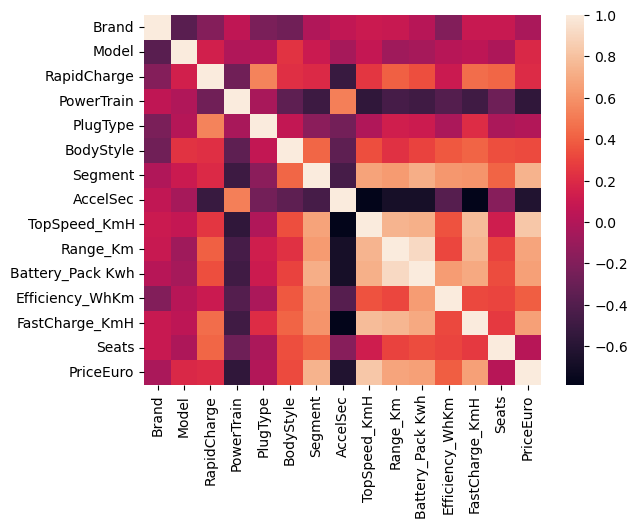

In [11]:
corealation_val = main_data.corr()
display(corealation_val)
sns.heatmap(corealation_val)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
x = main_data[['RapidCharge','PowerTrain','PlugType','BodyStyle','Segment','Seats',"FastCharge_KmH",'TopSpeed_KmH','Battery_Pack Kwh','FastCharge_KmH','Seats','Efficiency_WhKm']]
y = main_data['Range_Km']
x_train, x_test , y_train , y_test = train_test_split(x,y,random_state=42 , test_size=0.2)
x_train.shape, x_test.shape, y_train.shape , y_test.shape 


((81, 12), (21, 12), (81,), (21,))

In [13]:
from sklearn.linear_model import LinearRegression 
linear_model = LinearRegression()

In [14]:
linear_model.fit(x_train, y_train)

LinearRegression()

In [15]:
y_pred_train=linear_model.predict(x_train)
y_pred_test=linear_model.predict(x_test)

In [16]:
from sklearn.metrics import mean_absolute_error ,mean_squared_error,r2_score


In [17]:
print("MAE")
print("Train:",mean_absolute_error(y_true=y_train,y_pred=y_pred_train))
print("Test:",mean_absolute_error(y_true=y_test,y_pred=y_pred_test))

MAE
Train: 14.807400075211055
Test: 22.108872445040557


In [18]:
print("MSE")
print("Train:",mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print("Test:",mean_squared_error(y_true=y_test,y_pred=y_pred_test))

MSE
Train: 468.1031238848712
Test: 1338.0632636814375


In [19]:
print("R2_score")
print("Train:",r2_score(y_true=y_train,y_pred=y_pred_train))
print("Test:",r2_score(y_true=y_test,y_pred=y_pred_test))

R2_score
Train: 0.9708320926484998
Test: 0.898629829536769


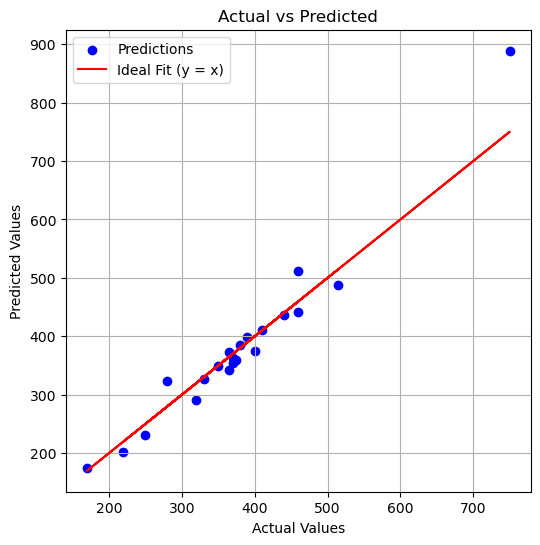

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, color='blue', label='Predictions')
plt.plot(y_test, y_test, color='red', label='Ideal Fit (y = x)')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()
